# Iris 데이터셋 Mean Shift 클러스터링

> 원본 실습파일(`01. 머신러닝 심화 Mean Shift Clustering.ipynb`)은 Wine 데이터셋을 사용합니다. 과제 지시에 따라 `load_wine` → `load_iris`로 교체하여 동일한 파이프라인을 그대로 적용했습니다.

## 개요
- Iris 데이터셋에 Mean Shift 알고리즘 적용
- 밀도 기반 클러스터링 수행
- 클러스터 개수 자동 탐지

## 주요 단계
1. 데이터 로드 및 정규화
2. PCA 차원 축소 (4차원 → 2차원)
3. 대역폭 추정 및 클러스터링
4. 결과 시각화
5. (추가) 실제 품종 라벨과의 일치도 확인

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import adjusted_rand_score

## 1. 데이터 로드 및 전처리

- Iris 데이터셋: 150개 샘플, 4개 피처(꽃받침 길이/너비, 꽃잎 길이/너비)
- StandardScaler로 정규화 (거리 기반 알고리즘 특성상 필수)

In [2]:
# 실습파일에서 데이터를 가져온 형태
# from sklearn.datasets import load_wine
# wine = load_wine()

# 과제를 수행하기 위해서 변경하여 적용해야하는 형태
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = iris.target  # 시각화/검증용 실제 품종 라벨 (클러스터링 자체에는 사용하지 않음)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")
print(f"\n데이터 미리보기:\n{X.head()}")

데이터 크기: (150, 4)

데이터 미리보기:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## 2. 차원 축소 (PCA)

- 4차원 → 2차원 축소
- 시각화 편의성 및 노이즈 완화

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.72962445 0.22850762]
총 설명된 분산: 95.81%


## 3. 대역폭 추정 및 모델 학습

**대역폭(Bandwidth)**
- 밀도 기반 점 이웃 반경 설정
- quantile=0.2: 상위 20% 거리 사용
- 데이터 밀도에 따라 자동 결정

In [4]:
bandwidth = estimate_bandwidth(X_pca, quantile=0.2, n_samples=len(X_pca))
print(f"추정된 Bandwidth: {bandwidth:.4f}")

추정된 Bandwidth: 1.0487


**Mean Shift 학습**
- bin_seeding=True: 초기 중심점 그리드 샘플링 (연산 속도 향상)

In [5]:
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_pca)

labels = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters_ = len(np.unique(labels))

print(f"발견된 클러스터 개수: {n_clusters_}")
print(f"\n클러스터 중심점:\n{cluster_centers}")

발견된 클러스터 개수: 3

클러스터 중심점:
[[ 1.33861206  0.23829271]
 [-2.21226386  0.17682952]
 [ 2.33034469  2.36799837]]


**클러스터별 샘플 개수**

In [6]:
for k in range(n_clusters_):
    count = np.sum(labels == k)
    print(f"클러스터 {k}: {count}개")

클러스터 0: 94개
클러스터 1: 52개
클러스터 2: 4개


## 4. 결과 시각화

- 색상 마커: 클러스터 라벨 구분
- 빨간색 X: 클러스터 중심점

C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 47553 (\N{HANGUL SYLLABLE RING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_4288\2071969677.py:10: UserWarning: Glyph 48156 (\N{HANGUL 

C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kimjongmin\AppData\Local\Python\pythoncore

C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kimjongmin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


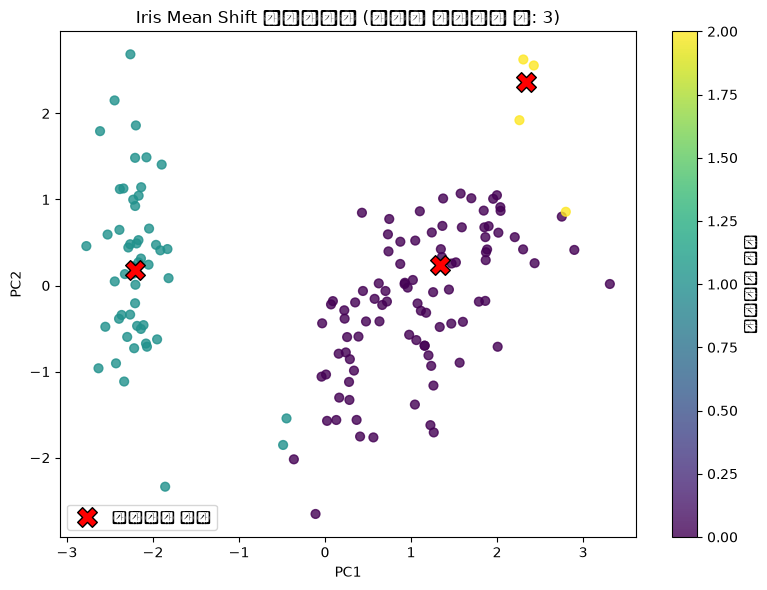

In [7]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=40, alpha=0.8)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
            c="red", marker="X", s=200, edgecolors="black", label="클러스터 중심")
plt.title(f"Iris Mean Shift 클러스터링 (발견된 클러스터 수: {n_clusters_})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.colorbar(scatter, label="클러스터 라벨")
plt.tight_layout()
plt.savefig("meanshift_result.png", dpi=100)
plt.show()

## 5. (추가) 실제 품종 라벨과의 일치도

Mean Shift는 비지도 학습이라 클러스터링 과정에서 실제 라벨(`y_true`)을 전혀 사용하지 않았다. 결과 검증 차원에서 Adjusted Rand Index(ARI)로 발견된 클러스터와 실제 품종(setosa/versicolor/virginica) 간 일치도만 사후에 계산해본다.

In [8]:
ari = adjusted_rand_score(y_true, labels)
print(f"Adjusted Rand Index (클러스터 vs 실제 품종): {ari:.4f}")

# 클러스터 vs 실제 품종 교차표
cross_tab = pd.crosstab(pd.Series(labels, name="cluster"), pd.Series(y_true, name="species"))
cross_tab.columns = [iris.target_names[i] for i in cross_tab.columns]
print("\n클러스터 x 실제 품종 교차표:")
print(cross_tab)

Adjusted Rand Index (클러스터 vs 실제 품종): 0.5401

클러스터 x 실제 품종 교차표:
         setosa  versicolor  virginica
cluster                               
0             0          48         46
1            50           2          0
2             0           0          4


## 오늘의 회고

Wine(13차원) 실습을 Iris(4차원)로 바꿔 돌려보니, Iris는 setosa가 나머지 두 품종과 워낙 뚜렷하게 분리되어 있어서 quantile=0.2 기준 대역폭으로도 Mean Shift가 비교적 안정적으로 클러스터를 찾아냈습니다. 다만 versicolor와 virginica는 PCA 2차원 공간에서도 경계가 겹치는 구간이 있어, 교차표로 확인했을 때 두 품종이 완전히 분리되지는 않았습니다. ARI 점수로 이 겹침 정도를 수치로 확인할 수 있었던 점이 유익했습니다.